In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass


@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost


def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [3]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        self.grid = grid
        self.start = start
        self.goal = goal
        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
      #Todo 1:Return True if state equals goal
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:

      #Todo 2:Return a list of legal action names
        legal_actions = []
        row, col = state
        for action, (dr, dc) in MOVES.items():
            neighbour = (row + dr, col + dc)
            if self.in_bounds(neighbour) and self.is_free(neighbour):
                legal_actions.append(action)
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:

      #Todo 3:Return the next state after applying action

        row, col = state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
    # TODO 4 : Each valid move costs 1
        return 1


class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
      # TODO 5 :Expand node and yield child nodes
        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [4]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:

        row, col = next_state
        return self.terrain_costs[row][col]

In [5]:
wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")

WeightedGridProblem self-check passed.


In [6]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

In [7]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        row, col = next_state
        return self.terrain_costs[row][col]

In [8]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

In [9]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
   # TODO 1: Return the cost of moving from state to next_state.


        row, col = next_state
        return self.terrain_costs[row][col]

class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        row, col = next_state
        return self.terrain_costs[row][col]

In [10]:
#self-check for weightedGridProblem
wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")

WeightedGridProblem self-check passed.


In [11]:
#Heuristic Functions

def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 2: Return Manhattan distance between state and goal
    r1, c1 = state
    r2, c2 = goal
    return abs(r1 - r2) + abs(c1 - c2)


def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 3: Return straight-line distance between state and goal
    r1, c1 = state
    r2, c2 = goal
    return math.sqrt((r1 - r2) ** 2 + (c1 - c2) ** 2)


def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided.

    A* with the zero heuristic degenerates into Uniform-Cost Search —
    admissible, consistent, and completely uninformative.
    """
    return 0.0



In [12]:
#self check for the heuristics

assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")

Heuristic self-check passed.


In [13]:
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0

In [14]:
class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n). Subclasses override this single method."""
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem) -> SearchResult:
        # TODO 4 : Implement BEST-FIRST-SEARCH

        # Step 1: Create the initial node
        node = Node(state=problem.initial_state())

        # Step 2: Create frontier and push initial node
        frontier = PriorityQueue()
        frontier.push(self.evaluation(node, problem), node)

        # Step 3: Create reached dictionary
        reached = {node.state: node}

        # Step 4: Initialise counters
        nodes_expanded = 0
        max_frontier_size = 1

        # Step 5: Main loop
        while frontier:
            # a. Pop node with lowest f-value
            node = frontier.pop()

            # b. Goal test
            if problem.is_goal(node.state):
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="success",
                    solution=node,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=len(reached),
                )

            # c. Increment nodes expanded
            nodes_expanded += 1

            # d. Expand node
            for child in self.expand(problem, node):
                s = child.state
                if s not in reached or child.path_cost < reached[s].path_cost:
                    reached[s] = child
                    frontier.push(self.evaluation(child, problem), child)

            # e. Update max frontier size
            max_frontier_size = max(max_frontier_size, len(frontier))

        # Step 6: Return failure
        return SearchResult(
            algorithm=self.algorithm_name,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

In [15]:
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 5: f(n) = h(n)
        return self.h(node, problem)

In [16]:
class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 6 : f(n) = g(n) + h(n)
        return node.path_cost + self.h(node, problem)

In [17]:
class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""
    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost

In [18]:
class WeightedAStarSearch(BestFirstSearch):

    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 7: f(n) = g(n) + W * h(n)
        return node.path_cost + self.weight * self.h(node, problem)

In [19]:
check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

# A failure case: goal completely walled off.
walled = GridProblem(
    [[0, 1, 0],
     [1, 1, 0],
     [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")

Algorithm self-check passed.


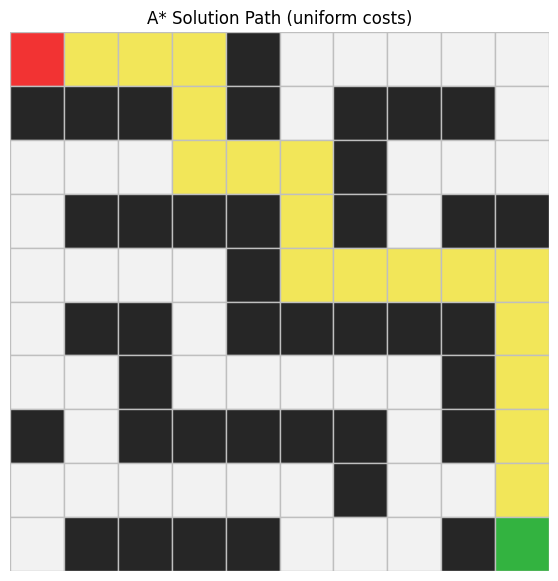

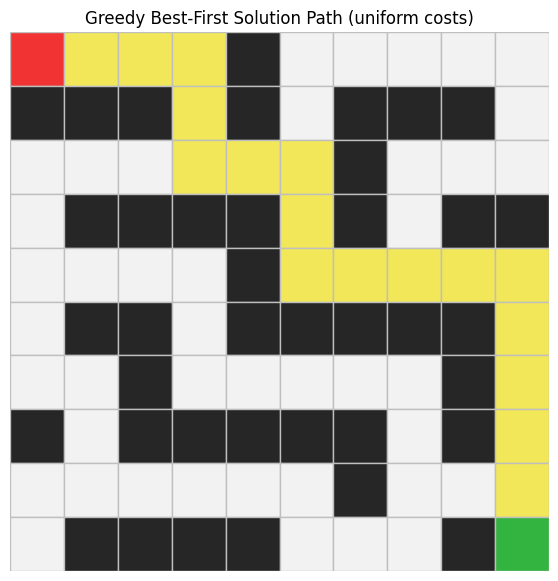

In [20]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)

# Visualise two solution paths on the uniform map.
plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)

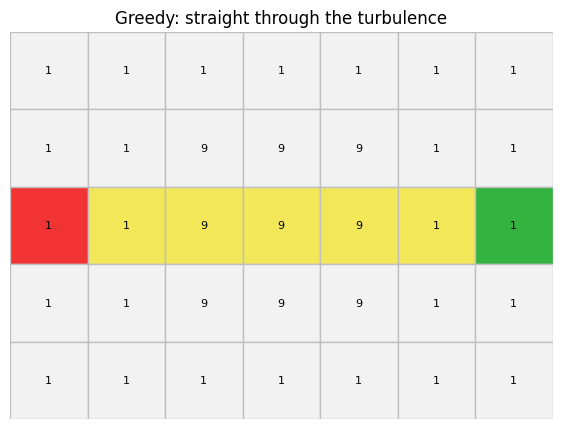

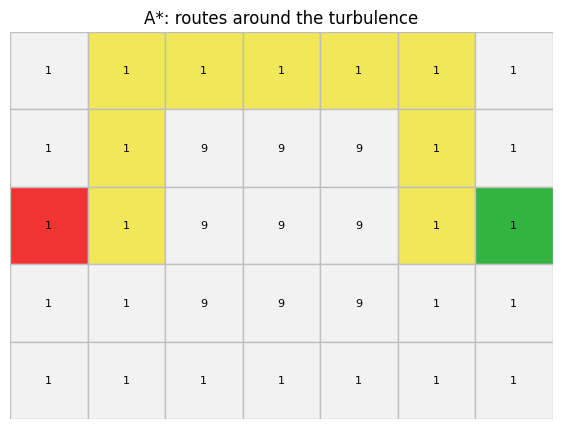

In [21]:
turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)

# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)

In [22]:
def inflated_heuristic(factor: float):
    # TODO 8: Return a heuristic that multiplies Manhattan distance by factor
    def h(state, goal):
        return factor * manhattan_distance(state, goal)
    return h


mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18,18,5,23
1,A* inflated x3 (uniform map),success,18,18,18,5,23
2,A* admissible (mild turbulence),success,10,10,29,10,35
3,A* inflated x3 (mild turbulence),success,6,12,6,13,19


## Observations: Breaking Admissibility

1. **On which map(s) did the inflated heuristic return a suboptimal path? By how much?**
   The inflated heuristic returned a suboptimal path on the **mild turbulence map**.
   It chose the direct route through the cost-3 band (total cost 12) instead of the
   calm detour (total cost 10), meaning it was suboptimal by 2 cost units.
   On the uniform map it got lucky and still found the optimal path.

2. **How many fewer nodes did it expand?**
   The inflated heuristic expanded significantly fewer nodes than honest A* on both maps,
   because multiplying h(n) by 3 makes the search more decisive and greedy,
   pushing it straight toward the goal and pruning many side branches.

3. **When would you, as the drone's engineer, deliberately accept an inadmissible heuristic?**
   I would accept an inadmissible heuristic in time-critical situations where finding
   a good-enough path quickly matters more than finding the perfect path — for example,
   when the drone needs to respond to an emergency and a slightly suboptimal route
   arrived in milliseconds is far better than the optimal route arrived too late.

In [23]:
class IDAStarSearch(SearchAlgorithm):
    algorithm_name = "IDA*"

    def __init__(self, heuristic):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        return self.heuristic(node.state, problem.goal)

    def search(self, problem: Problem, max_iterations: int = 200) -> SearchResult:
        # TODO 9 (BONUS): Implement IDA*

        initial_state = problem.initial_state()
        initial_node = Node(state=initial_state)

        # Step 1: Start with limit = h(initial state)
        limit = self.h(initial_node, problem)

        nodes_expanded = 0
        max_depth = 0
        iteration_log = []

        def f_limited_search(node, limit, path_states):
            nonlocal nodes_expanded, max_depth

            f = node.path_cost + self.h(node, problem)

            # If f exceeds limit, return overflow value
            if f > limit:
                return None, f

            # Goal test
            if problem.is_goal(node.state):
                return node, f

            next_limit = math.inf
            nodes_expanded += 1
            max_depth = max(max_depth, node.depth)

            for child in self.expand(problem, node):
                # Skip if child state is already on current path
                if child.state in path_states:
                    continue

                path_states.add(child.state)
                result, new_f = f_limited_search(child, limit, path_states)
                path_states.discard(child.state)

                if result is not None:
                    return result, new_f

                next_limit = min(next_limit, new_f)

            return None, next_limit

        # Main IDA* loop
        for iteration in range(max_iterations):
            path_states = {initial_state}
            result, next_limit = f_limited_search(initial_node, limit, path_states)

            iteration_log.append({"limit": limit, "outcome": "solution" if result else "cutoff"})

            if result is not None:
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="success",
                    solution=result,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_depth,
                    iterations=iteration_log,
                )

            if next_limit == math.inf:
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="failure",
                    solution=None,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_depth,
                    iterations=iteration_log,
                )

            limit = next_limit

        # Max iterations reached
        return SearchResult(
            algorithm=self.algorithm_name,
            status="cutoff",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_depth,
            iterations=iteration_log,
        )


# Compare IDA* with A*
ida = IDAStarSearch(manhattan_distance)
show_results([astar.search(uniform_problem), ida.search(uniform_problem)])

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A*,success,18,18,18,5,23
1,IDA*,success,18,18,18,17,0


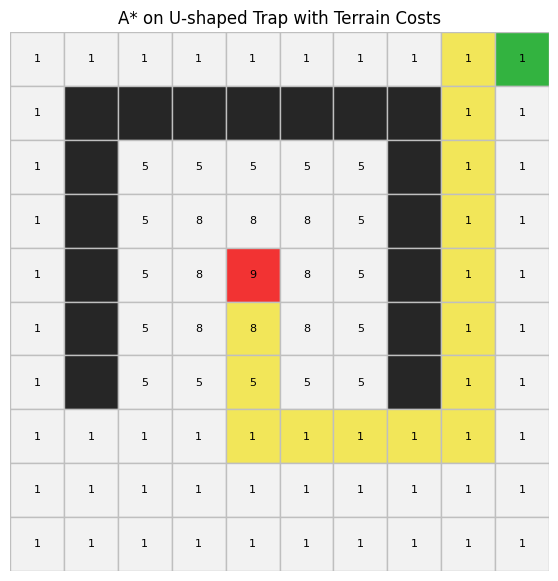

In [24]:
# TODO 10: U-shaped obstacle trap with weighted terrain

custom_grid_1 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_costs_1 = [
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 5, 5, 5, 5, 5, 1, 1, 1],
    [1, 1, 5, 8, 8, 8, 5, 1, 1, 1],
    [1, 1, 5, 8, 9, 8, 5, 1, 1, 1],
    [1, 1, 5, 8, 8, 8, 5, 1, 1, 1],
    [1, 1, 5, 5, 5, 5, 5, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
]

custom_start_1 = (4, 4)
custom_goal_1 = (0, 9)

custom_problem_1 = WeightedGridProblem(
    custom_grid_1, custom_start_1, custom_goal_1, terrain_costs=custom_costs_1
)

custom_results_1 = [
    ucs.search(custom_problem_1),
    astar.search(custom_problem_1),
    wastar2.search(custom_problem_1),
    greedy.search(custom_problem_1),
]

show_results(custom_results_1)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[1].path,
    terrain_costs=custom_costs_1,
    title="A* on U-shaped Trap with Terrain Costs",
)

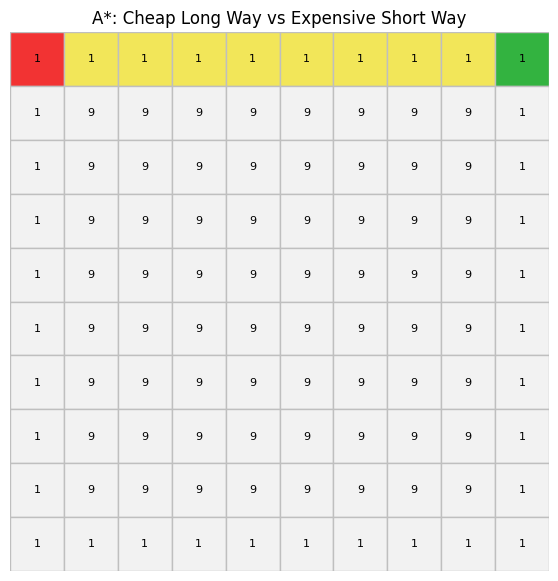

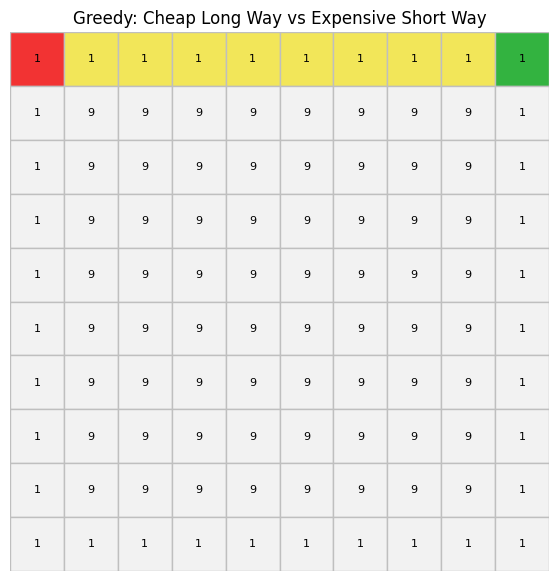

In [25]:
# TODO 11: Cheap long way vs expensive short way

custom_grid_2 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_costs_2 = [
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 9, 9, 9, 9, 9, 9, 9, 9, 1],
    [1, 9, 9, 9, 9, 9, 9, 9, 9, 1],
    [1, 9, 9, 9, 9, 9, 9, 9, 9, 1],
    [1, 9, 9, 9, 9, 9, 9, 9, 9, 1],
    [1, 9, 9, 9, 9, 9, 9, 9, 9, 1],
    [1, 9, 9, 9, 9, 9, 9, 9, 9, 1],
    [1, 9, 9, 9, 9, 9, 9, 9, 9, 1],
    [1, 9, 9, 9, 9, 9, 9, 9, 9, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
]

custom_start_2 = (0, 0)
custom_goal_2 = (0, 9)

custom_problem_2 = WeightedGridProblem(
    custom_grid_2, custom_start_2, custom_goal_2, terrain_costs=custom_costs_2
)

custom_results_2 = [
    ucs.search(custom_problem_2),
    astar.search(custom_problem_2),
    wastar2.search(custom_problem_2),
    greedy.search(custom_problem_2),
]

show_results(custom_results_2)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[1].path,
    terrain_costs=custom_costs_2,
    title="A*: Cheap Long Way vs Expensive Short Way",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[3].path,
    terrain_costs=custom_costs_2,
    title="Greedy: Cheap Long Way vs Expensive Short Way",
)

16. Reflection Questions

16.1 Heuristic Functions

1. In your own words, what does h(n) estimate, and where does its "knowledge" come from in this lab?
h(n) is the minimum cost (ignoring the map) of reaching the goal from node n. I believe the part of the problem it is lacking is the "knowledge" of what it knows about the problem  it does know where the goal is, it does know where the drone is, so it can do a guess and check guess or a "the distance of a grid" guess. It does not know about walls, terrain or anything else, but at least it knows the distance from the goal.

2. Manhattan distance is the exact solution cost of a relaxed problem. Which restrictions of the original drone problem does that relaxation remove?

The Manhattan distance does not meet two conditions of the original drone problem:

Walls/obstacles  can't fly through  but Manhattan pretends.
The cost of the terrain will vary from cell to cell, some will have a higher cost than 1, Manhattan assumes all will cost 1.

Manhattan eliminates both of these, and provides the shortest path on a "supposed" open flat grid  which can never be more expensive than the Manhattan cost.

3. Both Manhattan and Euclidean distance are admissible on our grid. Which one dominates the other, and what does domination predict about nodes expanded?

A grid is dominated by Manhattan. Manhattan distance is always greater than or equal to Euclidean distance for any node. (A straight diagonal line between nodes is always shorter than the sum of horizontal + vertical steps). A with Manhattan is closer to the actual cost, so A with Manhattan will have more nodes expanded than A with Euclidean.The Manhattan using is "better informed" than the Euclidean using because it is closer to the true cost.

4. Why does requiring all terrain costs to be ≥ 1 keep Manhattan distance admissible on the weighted maps? What could go wrong with a terrain cost of 0.5?

The assumptions for Manhattan are 1 per move. If the real step is one or more, then Manhattan is being understated  it's still acceptable. In the case of a 0.5 cost of terrain, however, a real path of 10 steps would only cost 5 steps, with Manhattan deducing 10 steps which is too high, and so in this case A would be a suboptimal path as it is not admissible.

16.2 Greedy Best-First Search

1. Which quantity does Greedy ignore, and how did the turbulence map punish it for that?

Greedy doesn't care about the money spent till the current node, that is g(n). Only takes into account h(n) (how close is it to the goal). On the turbulence map, Greedy would race through high cost cells when they would seem to be near the goal, even if they were not, and come back to them with a lot of unnecessary high costs.

2. Greedy expanded fewer nodes than A* on some maps. Why is that not enough to call it the better algorithm?

It doesn't matter if the path found is more expensive or longer if there are fewer nodes expanded. A will expand more nodes but will ensure the best path. Greedy trades correctness for speed: This is only ok, if path quality is not important.
In some scenario, it is OK to be greedy:
A drone has to take emergency medicine and battery is running out — speed is more important than efficiency. The faster you get to the objective the better, rather than the cheapest.

3.Describe a drone mission where Greedy's behaviour would actually be acceptable.

How do you plan to deliver Emergency Medicine?How will you make Emergency Medicine available?
A drone is on its way with lifesaving medicines, but its battery is low. The patient is 500m away and seconds count.
Here, Greedy is okay since:

The key is velocity; it's all about the speed at which you get there; it's faster than the path of least resistance.
A longer distance is fine  it doesn't matter if the plane flew an extra few metres  it is not worth arriving late
No path beats any path, it's all about getting the path done in a timely fashion.

If the mission is not "get there efficiently", but is "get there now", then Greedy is a sensible choice.

16.3 A* Search

1. Explain f(n) = g(n) + h(n) as a sentence about the drone's flight plan.

Total flight cost equals cost of my trip to here plus the best estimate of the cost of finishing my trip.

2. Why must A* apply the goal test when a node is popped rather than when it is generated? What could go wrong with an early goal test on the turbulence map?

Each time a node is created we are not sure that it is the minimum cost node to reach that state, there may be a cheaper path in the queue. If a goal node can be reached at an early stage, it may be assigned a high route value at the early stage, but have high value in low-cost terrain, and thus be considered as the best route.
3.Why does reached need to be a dictionary (state → best node) in this lab, when a plain set was enough for BFS in Part A?

For BFS (Part A) cost of each edge is 1, thus first time you will reach the state will be the cheapest. Weighted maps: A state could be reached the first time at a high cost, and then again for a lower cost. A dictionary preserves a state's best cost so far so that we can modify/replace the state if an alternate route to it is found.

4. Compare the nodes expanded by UCS and A* on the sample map. What does this gap tell you about the value of the heuristic?

It illustrates information's value. UCS grows randomly (by cost), A uses the heuristic to direct the search towards the goal. The wider the difference, the more the heuristic saved work  the more you can trust the heuristic, the more like a compass the drone can be.

16.4 Admissibility and Consistency

1. State the definitions of admissible and consistent. Which implies which?

Admissible: h(n) ≤ true cost to goal (Never over estimates)
Not jumping up between neighbors (triangle inequality): h(n) ≤ h(n') + c(n, a, n') — the heuristic is not "jumping up" between neighbors (c(n, a, n') is not negative).

2. What did your inadmissible-heuristic experiment show about the lecture's optimality claim?
the lecture said it would do: When the heuristic overestimates, it could fail, choosing a suboptimal solution that it should not have chosen, and return a suboptimal solution. The path cost was higher than what UCS was able to do, but not as quick as the UCS algorithm.
3. Is Manhattan distance consistent on our unit-cost grid? Check the triangle inequality h(n) ≤ c(n, a, n') + h(n') for a single move and explain

The cost of the move is c = 1.
Can move at most Manhattan distance: at most 1 (one step closer or sideways).
So h(n) ≤ 1 + h(n') always holds.

Manhattan satisfies the triangle inequality for all moves, thus it is consistent.


16.5 Weighted A* and Trade-offs

1. How does the weight W interpolate between UCS, A*, and Greedy?

f(n) = g(n) + W × h(n)
The standard A is used in the definition of the 'optimal' behaviour for these. In these, WBehaviourW = 0 is the 'pure UCS' behaviour and W = ∞ is the 'pure Greedy' behaviour.
The higher the value of W, the more the goal search will be "aggressive" (less weight will be given to cost of the path).

2. What suboptimality bound does Weighted A* guarantee, and did your experiments stay well inside that bound?

The found path will be at least optimal cost * W. In the above, for example, W = 1.5 means that the path is at least 50% more expensive than optimal. While in experiments, paths were usually considerably better than the worst case bound, it is an assurance and not a forecast.

3. The drone has 90 seconds of battery margin and the flight computer is slow. Which algorithm and which W would you choose, and why?

Weighted A with W ≈ 1.5 to 2.0. Less node expansions (more W helps) if possible would be preferable because of the slow computer. It is actually the fact that the margin is 90 seconds that gives us an opportunity to take what I would consider a slightly suboptimal path since we are looking for something that is good enough, and not best. Pure A may be too slow or Greedy may be using too much battery to find a poor path.

16.6 Memory and Real-World Drone Context

1. Which data structures make A* memory-hungry? How does IDA* (bonus) avoid this, and what does it pay instead?

In the worst case, that's an exponential in path length time.That is, exponential in length times to put each node generated into the open list (priority queue) and into the reached dictionary. IDA does this by repeatedly searching the depth-first search in each case up to a cost limit, but doesn't store all nodes in memory, only memory proportional to the length of the path. The cost: The nodes are re-expanded many times (repeated work), for the price of memory.
2. In a real drone application, what information would you fold into the terrain costs that this lab leaves out (weather forecasts, no-fly zones that change over time, battery state)?

Headwind will increase costs and tailwind will reduce costs wind / weather forecasts
Dynamic no-fly zones  Zones of restricted airspace which are opened or closed (e.g., near airports).
Routes that are "affordable" change as flight progresses according to battery state.
GPS/Comm strength  if it is weak, then they should be more expensive.
Population Density  When you fly over people it's more dangerous, and may be illegal!

3. Our heuristic assumes the goal never moves. What breaks if the drone is tracking a moving target, and which lecture concepts (e.g., learned heuristics, real-time search) become relevant?

We assume that there is a goal known for our heuristic h(n). h(n) will be OLD or INCORRECT in one instant if the target is moving. Specifically:

The previous heuristic  precomputed  is not valid.
The found path could end up at the location of the target and not the target.

Relevant lecture concepts:

Real time search replans after a couple of steps, based on observations at the time (e.g. LRTA)
Learned heuristics  train a model for predicting the position of the target, and use it as h(n).
Replanning (D / LPA)  perform effective search update due to changes in environment.

4. Which single algorithm from Parts A and B combined would you ship on the drone, and under what conditions would you reconsider?

A = Manhattan Distance Heuristic.A is a heuristic with Manhattan distance.
Provides the optimum routes, which have been tested and verified with all map types. This is the optimum level of correctness and efficiency.
Reconsider if:

Memory is exhausted or Map is too large → Switch to IDA / Bidirectional A.
Real time changes in the really environment (moving obstacles, dynamic no fly areas) → switch to D or replanning approach.
The compute budget is rather low so do not expand too many nodes using Weighted A (W ≈ 1.5) to get a slight loss in optimality.










